In [1]:
from pathlib import Path
import os
import sys

import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import copernicusmarine
import shutil

import cartopy.crs as ccrs
import cartopy.feature as cfeature

c:\Users\pesen\Documents\UCL Masters Coursework\Masters Project SWOT\swot_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from display_tracks import display_1D_tracks, get_spatial_density
from copernicus_pipeline import fetch_and_store_satellites, load_experiment_dataset, combine_for_drf, process_and_split_dataframe, store_tensors

In [3]:
example_experiment = {
    "name": "example_experiment",
    "satellites": [
        {"name": "", "freq": ""},
        {"name": "", "freq": ""}
        # etc.
    ],
    "start_date": "2024-01-01",
    "end_date": "2024-01-02",
    "variables": ["sla_filtered", ""]#etc.
}

In [4]:
test_experiment1 = {
    "name": "test_experiment1",
    "satellites": [
        {"name": "swot_nadir", "freq": "1hz"},
        {"name": "jason3_interleaved", "freq": "1hz"}
    ],
    "start_date": "2023-11-07",
    "end_date": "2023-11-13",
    "variables": ["sla_filtered"]
}

In [5]:
test_experiment2 = {
    "name": "test_experiment2",
    "satellites": [
        {"name": "swot_nadir", "freq": "1hz"},
        {"name": "jason3_interleaved", "freq": "1hz"}
    ],
    "start_date": "2024-01-01",
    "end_date": "2024-01-15",
    "variables": ["sla_filtered"]
}

In [6]:
baseline_experiment = {
    "name": "baseline_jason_cryosat",
    "satellites": [
        {"name": "jason3_interleaved", "freq": "1hz"},
        {"name": "cryosat2", "freq": "1hz"}
    ],
    "start_date": "2023-01-01",
    "end_date": "2023-12-31",
    "variables": ["sla_filtered"]
}

In [7]:
all_sats_1_day_experiment = {
    "name": "all_sats_1_day_experiment",
    "satellites": [
        {"name": "swot_nadir", "freq": "1hz"},
        {"name": "jason3_interleaved", "freq": "1hz"},
        {"name": "jason3_LRO", "freq": "1hz"},
        {"name": "cryosat2", "freq": "1hz"},
        {"name": "sentinel3a", "freq": "1hz"}
    ],
    "start_date": "2026-06-01",
    "end_date": "2026-06-02",
    "variables": ["sla_filtered"]
}

In [10]:
all_sats_15_days_experiment = {
    "name": "all_sats_15_days_experiment",
    "satellites": [
        {"name": "swot_nadir", "freq": "1hz"},
        {"name": "jason3_interleaved", "freq": "1hz"},
        {"name": "jason3_LRO", "freq": "1hz"},
        {"name": "cryosat2", "freq": "1hz"},
        {"name": "sentinel3a", "freq": "1hz"}
    ],
    "start_date": "2026-06-01",
    "end_date": "2026-06-16",
    "variables": ["sla_filtered"]
}

In [11]:
small_experiment = {
    "name": "small_experiment",
    "satellites": [
        {"name": "swot_nadir", "freq": "1hz"}
    ],
    "start_date": "2024-01-01T00:00:00",
    "end_date": "2024-01-01T01:00:00",
    "variables": ["sla_filtered"]
}

In [12]:
swot_5hz_experiment = {
    "name": "swot_5hz_experiment",
    "satellites": [
        {"name": "swot_nadir", "freq": "5hz"}
    ],
    "start_date": "2024-01-01T00:00:00",
    "end_date": "2024-01-01T01:00:00",
    "variables": ["sla_filtered"]
}

Running Locally (Windows).

--- Fetching swot_nadir (1hz) from Copernicus ---


INFO - 2026-08-14T17:09:23Z - Selected dataset version: "202311"
INFO - 2026-08-14T17:09:23Z - Selected dataset part: "default"
100%|██████████| [00:20<00:00]
INFO - 2026-08-14T17:10:44Z - Produced 1 NetCDF file(s) in data\temp\raw_nc\cmems_obs-sl_glo_phy-ssh_nrt_swon-l3-duacs_PT1S_sla_filtered_2026-06-01-2026-06-16


Found 1 NetCDF file(s). Converting to Zarr...


c:\Users\pesen\Documents\UCL Masters Coursework\Masters Project SWOT\swot_env\Lib\site-packages\zarr\api\asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Transferring to Google Drive...
Saved swot_nadir to G:\My Drive\SWOT Project\data\zarr files\swot_nadir\swot_nadir_1hz_2026-06-01_2026-06-16.zarr

--- Fetching jason3_interleaved (1hz) from Copernicus ---


...

Transferring to Google Drive...
Saved cryosat2 to G:\My Drive\SWOT Project\data\zarr files\cryosat2\cryosat2_1hz_2026-06-01_2026-06-16.zarr

--- Fetching sentinel3a (1hz) from Copernicus ---


INFO - 2026-08-14T17:13:58Z - Selected dataset version: "202311"
INFO - 2026-08-14T17:13:58Z - Selected dataset part: "default"
100%|██████████| [00:32<00:00]
INFO - 2026-08-14T17:15:33Z - Produced 1 NetCDF file(s) in data\temp\raw_nc\cmems_obs-sl_glo_phy-ssh_nrt_s3a-l3-duacs_PT1S_sla_filtered_2026-06-01-2026-06-16


Found 1 NetCDF file(s). Converting to Zarr...


c:\Users\pesen\Documents\UCL Masters Coursework\Masters Project SWOT\swot_env\Lib\site-packages\zarr\api\asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Transferring to Google Drive...
Saved sentinel3a to G:\My Drive\SWOT Project\data\zarr files\sentinel3a\sentinel3a_1hz_2026-06-01_2026-06-16.zarr
Running Locally (Windows).


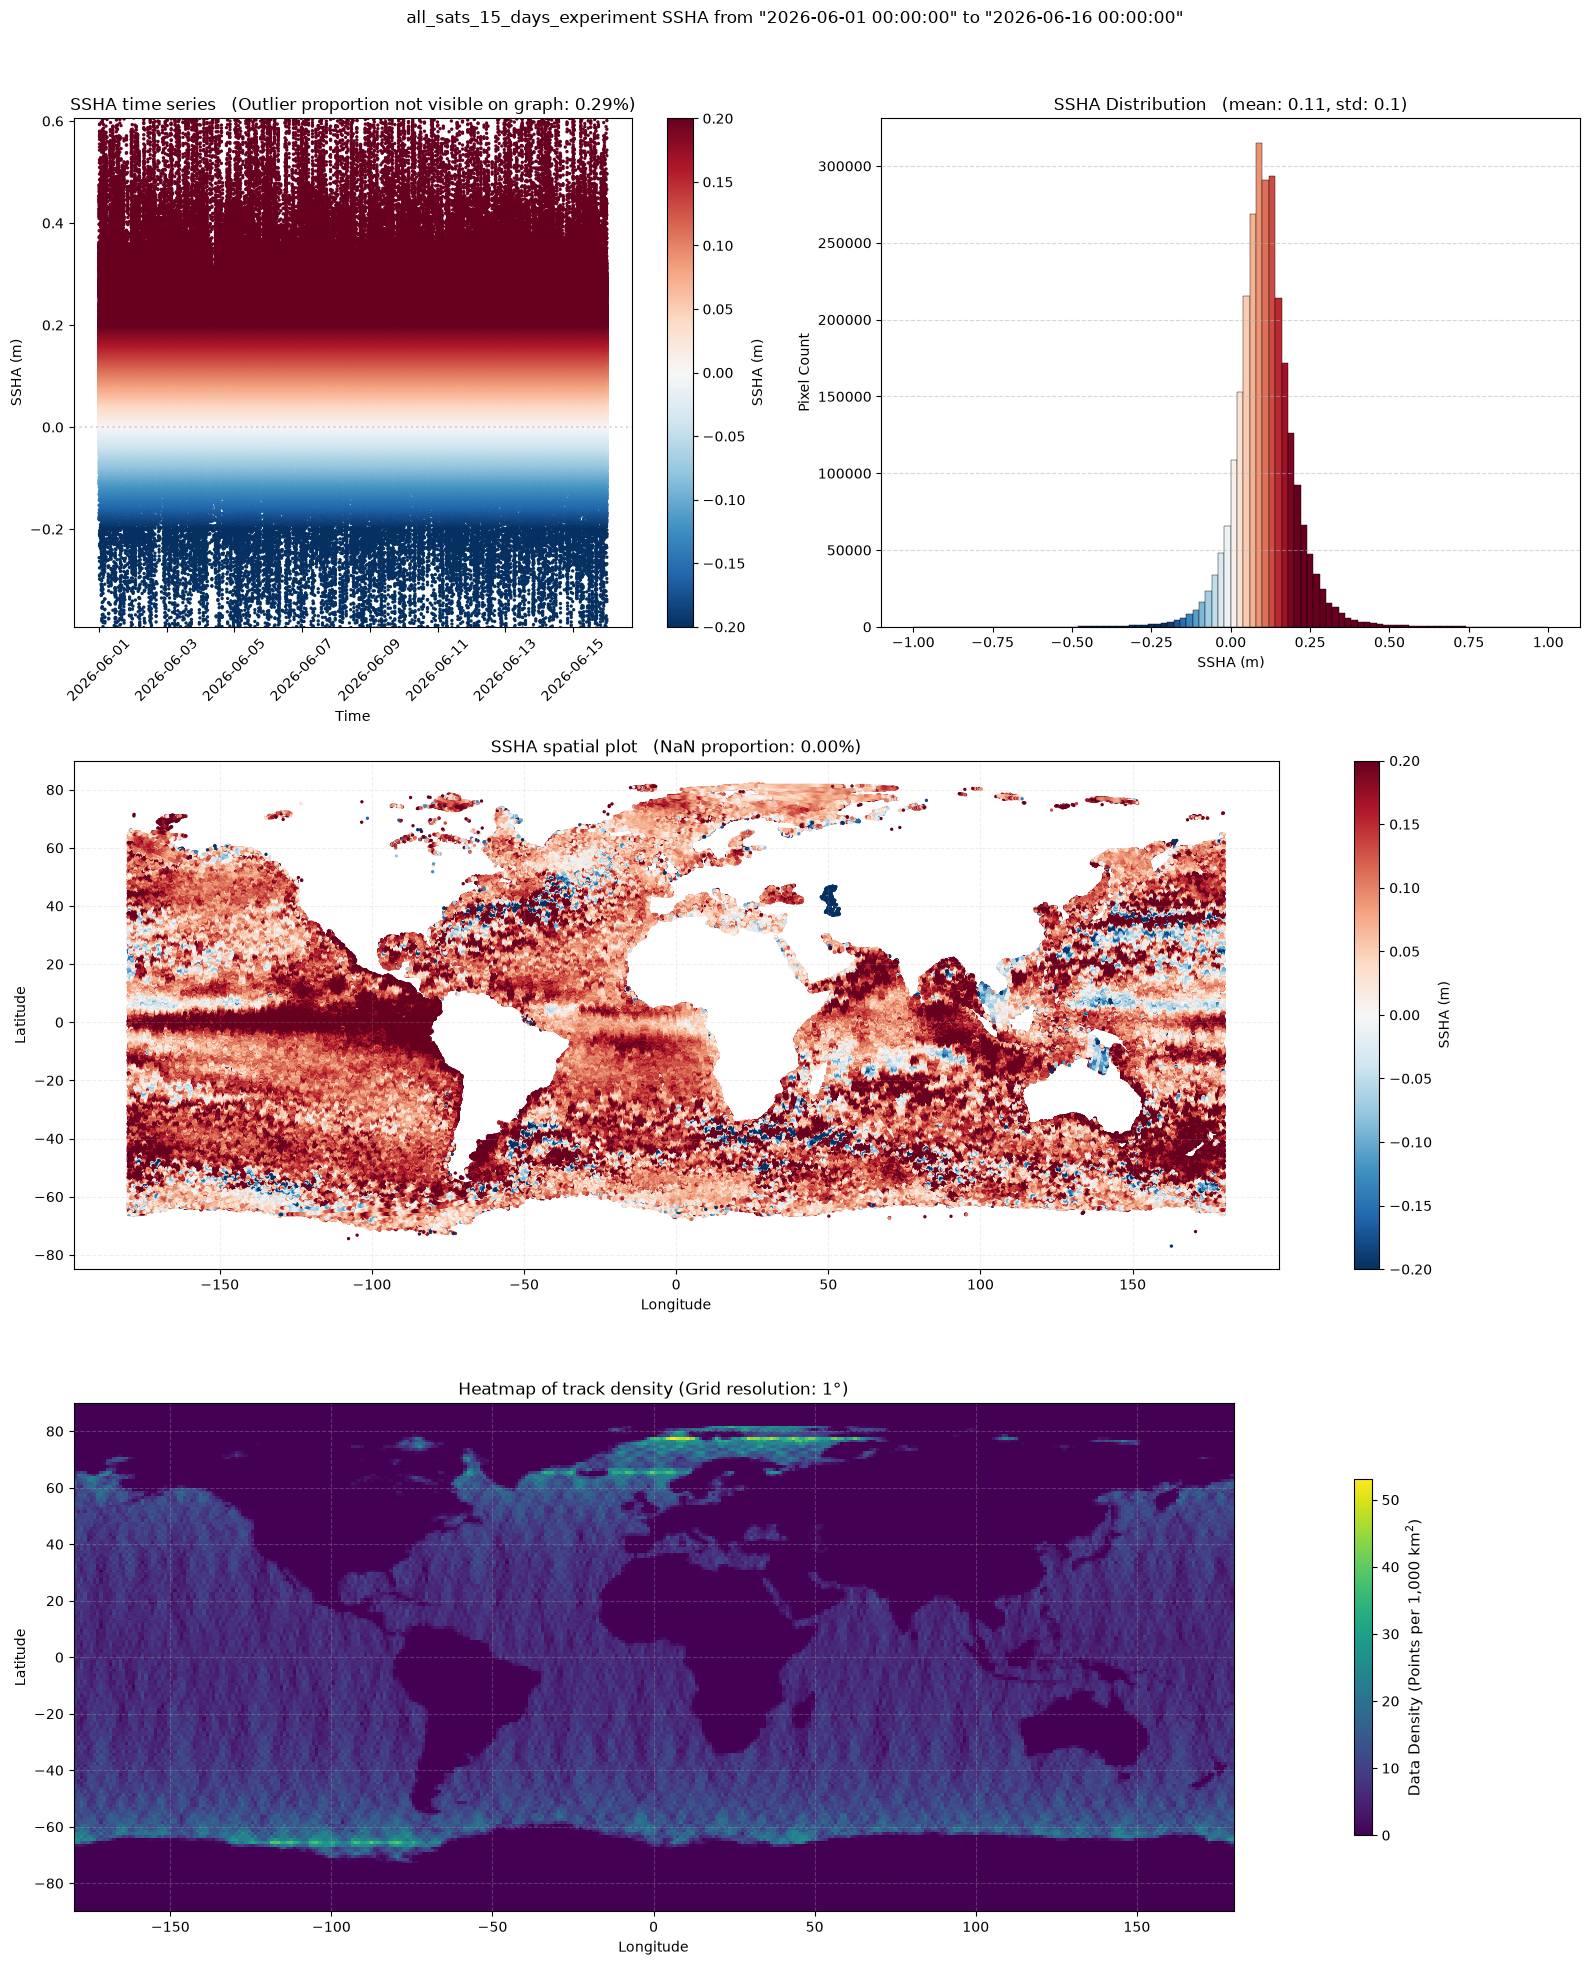

,time,sla_filtered,latitude,longitude,satellite
0,2026-06-01 00:00:00,0.131,-11.211591,-94.656900,jason3_LRO
1,2026-06-01 00:00:00,0.043,-59.715183,-159.601410,cryosat2
2,2026-06-01 00:00:01,0.133,-11.162601,-94.638490,jason3_LRO
3,2026-06-01 00:00:01,0.032,-59.771780,-159.613250,cryosat2
4,2026-06-01 00:00:02,0.137,-11.113609,-94.620094,jason3_LRO
...,...,...,...,...,...
2726932,2026-06-15 23:59:59,0.043,29.768560,-121.294975,jason3_LRO
2726933,2026-06-15 23:59:59,0.024,-54.422943,137.940460,sentinel3a
2726934,2026-06-16 00:00:00,0.108,58.878433,153.872630,swot_nadir
2726935,2026-06-16 00:00:00,0.037,29.816025,-121.270360,jason3_LRO


Running Locally (Windows).
Saved all_sats_15_days_experiment to G:\My Drive\SWOT Project\data\pytorch tensors\all_sats_15_days_experiment.pt


In [13]:
# Set experiment to test
experiment = all_sats_15_days_experiment

fetch_and_store_satellites(experiment)

data_dict = load_experiment_dataset(experiment)

ds = combine_for_drf(data_dict, "xarray")

display_1D_tracks(ds, experiment["name"], dot_size=2)

df = combine_for_drf(data_dict, "pandas")

display(df)

processed_tensors = process_and_split_dataframe(df)

store_tensors(processed_tensors, experiment["name"])



: 